In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt                        # For Plotting
import seaborn as sns                                  # For Plotting
from sklearn.metrics import log_loss                   # For Model Evaluation
from sklearn.model_selection import RepeatedKFold      # For Cross-Validation

In [2]:
data = pd.read_csv("/content/train.csv")

In [3]:
data.head()

,Id,Review,Components,Delivery and Customer Support,Design and Aesthetics,Dimensions,Features,Functionality,Installation,Material,Price,Quality,Usability,Polarity
0,0,For some reason everybody complains and I'm co...,0,0,0,0,0,0,0,0,0,0,1,0
1,1,"I like everything about it, great choice of sp...",0,0,0,0,1,1,0,0,0,0,0,1
2,2,Excellent ceiling fan brace. Easy to install a...,0,0,0,0,0,0,1,0,0,1,0,1
3,3,Work great easy to use . No issues at all with...,0,0,0,0,0,1,0,0,0,0,1,1
4,4,I would recommend this product because it is p...,0,0,0,0,0,0,0,0,0,1,0,1


In [4]:
data.columns

Index(['Id', 'Review', 'Components', 'Delivery and Customer Support',
       'Design and Aesthetics', 'Dimensions', 'Features', 'Functionality',
       'Installation', 'Material', 'Price', 'Quality', 'Usability',
       'Polarity'],
      dtype='object')

In [5]:
data.isnull().sum()

,0
Id,0
Review,0
Components,0
Delivery and Customer Support,0
Design and Aesthetics,0
Dimensions,0
Features,0
Functionality,0
Installation,0
Material,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6136 entries, 0 to 6135
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Id                             6136 non-null   int64 
 1   Review                         6136 non-null   object
 2   Components                     6136 non-null   int64 
 3   Delivery and Customer Support  6136 non-null   int64 
 4   Design and Aesthetics          6136 non-null   int64 
 5   Dimensions                     6136 non-null   int64 
 6   Features                       6136 non-null   int64 
 7   Functionality                  6136 non-null   int64 
 8   Installation                   6136 non-null   int64 
 9   Material                       6136 non-null   int64 
 10  Price                          6136 non-null   int64 
 11  Quality                        6136 non-null   int64 
 12  Usability                      6136 non-null   int64 
 13  Pol

In [7]:
data.shape

(6136, 14)

([<matplotlib.patches.Wedge at 0x78b6f50efd10>,
 [Text(-0.8417633550181225, 0.7081203669918233, '1'),
  Text(0.8417634169239703, -0.708120293402528, '0')],
 [Text(-0.4591436481917031, 0.38624747290463085, '1.1f%'),
  Text(0.45914368195852917, -0.3862474327650152, '1.1f%')])

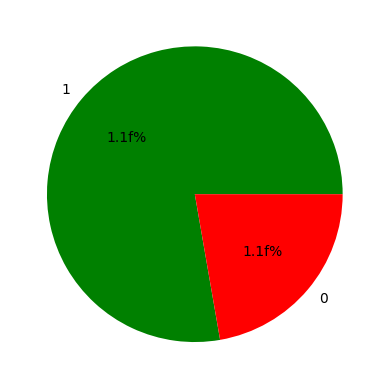

In [9]:
sentiment_count = data.Polarity.value_counts()
sentiment_type = data.Polarity.value_counts().index                # 1- Positive    0- Negative
plt.pie(sentiment_count,labels=sentiment_type, autopct='1.1f%%',colors=['green', 'red'])

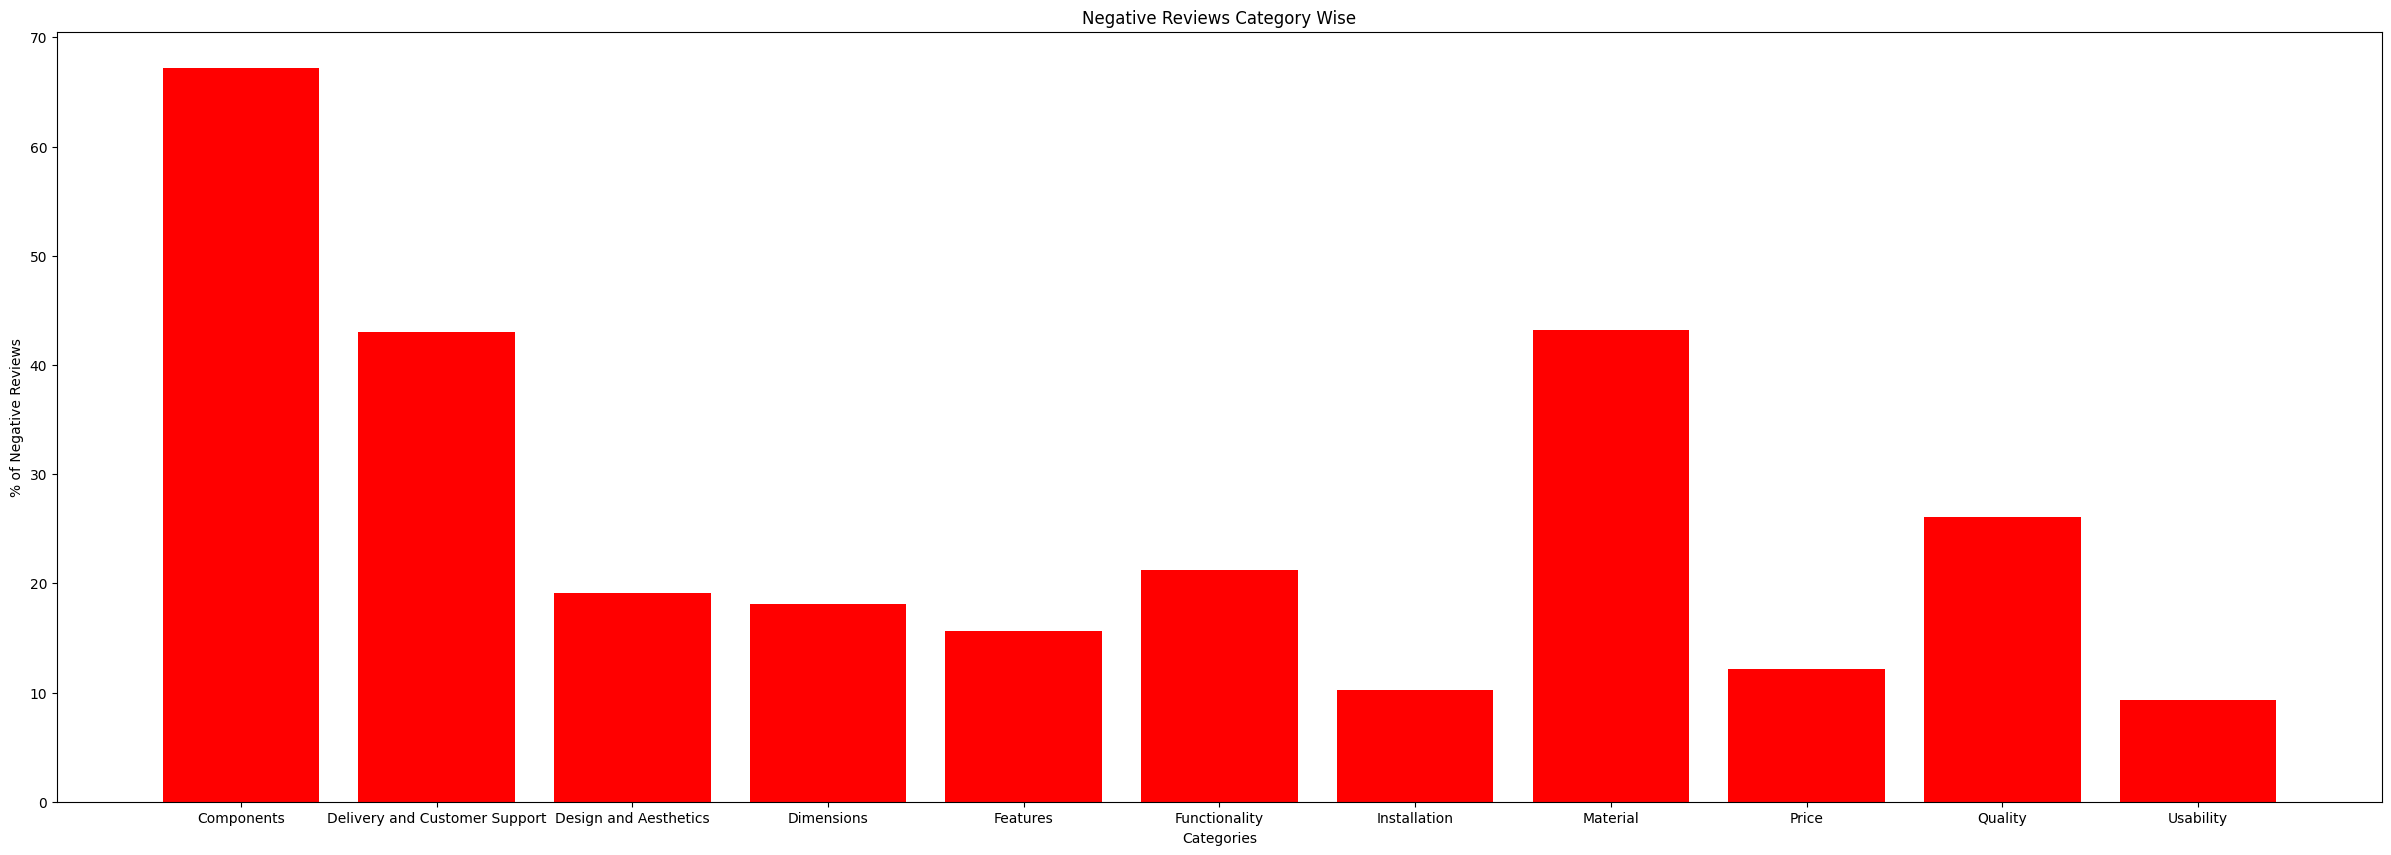

In [10]:
col = ['Components', 'Delivery and Customer Support',
       'Design and Aesthetics', 'Dimensions', 'Features', 'Functionality',
       'Installation', 'Material', 'Price', 'Quality', 'Usability']
negative_category=[]
for i in col:
    k = ((data[i].sum()-data[data[i]==1]['Polarity'].sum())/data[i].sum())*100
    negative_category.append(k)
fig = plt.figure(figsize = (30, 10))
plt.bar(col,negative_category,color ='red')
plt.xlabel("Categories")
plt.ylabel("% of Negative Reviews")
plt.title("Negative Reviews Category Wise")
plt.show()


In [12]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r"what's", "what is ", text)
    text = re.sub(r"'s", " ", text)
    text = re.sub(r"'ve", " have ", text)
    text = re.sub(r"can't", "can not ", text)
    text = re.sub(r"n't", " not ", text)
    text = re.sub(r"i'm", "i am ", text)
    text = re.sub(r"'re", " are ", text)
    text = re.sub(r"'d", " would ", text)
    text = re.sub(r"'ll", " will ", text)
    text = text.strip(' ')

    return text
    data['Review'] = data['Review'].map(lambda com : clean_text(com))
data['Review'][0]

"For some reason everybody complains and I'm complaining now about my toilet that I just boughtFor some reason it's not ceiling from the tank to the pedestal I can't get it sealed without cracking the toilet support design for some reason I'm very unhappy with his toilet never buy American standard again"

In [15]:
#!pip install nltk
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
data['Review'] = data['Review'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))
data['Review'][0]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


"For reason everybody complains I'm complaining toilet I boughtFor reason ceiling tank pedestal I can't get sealed without cracking toilet support design reason I'm unhappy toilet never buy American standard"

In [18]:
y = np.array(data[[ 'Components', 'Delivery and Customer Support',
       'Design and Aesthetics', 'Dimensions', 'Features', 'Functionality',
       'Installation', 'Material', 'Price', 'Quality', 'Usability','Polarity']])
X = data['Review']
X.head(5)

X.shape

(6136,)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
X = data['Review'] # Ensure X is defined for this cell
vectorizer = TfidfVectorizer(min_df=20,ngram_range=(1,4), max_features=250)
vectorizer.fit(X)
X = vectorizer.transform(X)  # Taking X as input and converting into feature matrix(numerical values)
X = X.todense()

In [21]:
!pip install tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.initializers import RandomNormal
def get_model(n_inputs, n_outputs):
  batch_size = 256
  hidden_units = 64
  dropout = 0.2

  model = Sequential()
  model.add(Dense(hidden_units, input_dim=n_inputs,activation='relu',
          kernel_initializer='he_uniform'))
  model.add(Dropout(dropout))
  model.add(Dense(64,activation='relu',
          kernel_initializer='he_uniform'))
  model.add(Dropout(dropout))
  model.add(Dense(n_outputs))
  model.add(Activation('sigmoid'))
  model.compile(loss='binary_crossentropy', optimizer='adam')
  return model
import tensorflow as tf
def evaluate_model(X,y):
  results_test = []
  results_train =[]
  callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5,min_delta = 0.05)
  n_inputs, n_outputs = X.shape[1], y.shape[1]
  cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
  for train_ix,test_ix in cv.split(X):
    X_train, X_test = X[train_ix], X[test_ix]
    y_train,y_test = y[train_ix],y[test_ix]
    model = get_model(n_inputs, n_outputs)
    model.fit(X_train,y_train,verbose = 0,epochs = 50,callbacks = callback)
    yhat_train = model.predict(X_train)
    yhat_test = model.predict(X_test)
    train_log_loss = log_loss(y_train, yhat_train)
    test_log_loss = log_loss(y_test,yhat_test)
    results_train.append(train_log_loss)
    results_test.append(test_log_loss)
  return results_train,results_test,model
results_train,results_test,model = evaluate_model(X, y)
print(results_train)
print(results_test)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
[1.3910647993528562, 1.4967518585208768, 1.5024172940980867, 1.5324608233353652, 1.5558568274063118, 1.5120134626711175, 1.5721888807728082, 1.4803689219901055, 1.5554411347920378, 1.5584373932383353, 1.5947967688517466, 1.5419237096889755, 1.4842477683773236, 1.501108831595756, 1.5365039277022554, 1.5267693451641395, 1.5576080873950673, 1.5746042657278736, 1.5334900923232686, 1.498624955578601, 1.4645859869054585, 1.5318381356488169, 1.5022528158983983, 1.5272568930607988, 1.5322790133494943, 1.5178081524697098, 1.5317276810647598, 1.4825345257937945, 1.5431400821545724, 1.5300608229453063]
[1.6440979828775937, 1.541136954899751, 1.658943122774072, 1.7127102830832581, 1.6293698294464976, 1.6523529733683493, 1.853655993009059, 1.570918945236236, 1.7081940519401304, 1.710313583408798, 1.7430234057153229, 1.6321015371141396, 1.704200414067489, 1.6126751291362391, 1.6762079906837848, 1.4999720837821027, 1.842

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


In [23]:
print(sum(results_train)/len(results_train))
print(sum(results_test)/len(results_test))

1.5223387752624673
1.672599200233146


In [24]:
test_data = pd.read_csv("/content/test.csv")
test_data.head(5)

,Id,Review,Components,Delivery and Customer Support,Design and Aesthetics,Dimensions,Features,Functionality,Installation,Material,Price,Quality,Usability,Polarity
0,0,Made of very thin cheap metal broke on very fi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,"As good as the brand names, no jams or misfire...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,"unit was easy to use, with understandable in s...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,I am the new family plumber. Works well. No pr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Seems to be holding up well.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
test_data['Review'] = test_data['Review'].map(lambda com : clean_text(com))
test_data['Review'] = test_data['Review'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))
test_vectorised_data = vectorizer.transform(test_data['Review'] )
test_vectorised_data = test_vectorised_data.todense()

In [26]:
prediction_on_test_data = model.predict(test_vectorised_data)
df_test = pd.DataFrame(prediction_on_test_data, columns = ['Components', 'Delivery and Customer Support',
       'Design and Aesthetics', 'Dimensions', 'Features', 'Functionality',
       'Installation', 'Material', 'Price', 'Quality', 'Usability',
       'Polarity'])
df_test

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Components,Delivery and Customer Support,Design and Aesthetics,Dimensions,Features,Functionality,Installation,Material,Price,Quality,Usability,Polarity
0,0.119895,0.063057,0.068863,0.038302,0.083385,0.138188,0.027834,0.089305,0.081514,0.882833,0.022023,0.167842
1,0.013061,0.020124,0.019990,0.107511,0.028116,0.758702,0.005900,0.001693,0.095482,0.085402,0.022190,0.926149
2,0.002606,0.001364,0.033216,0.029456,0.052433,0.089026,0.006151,0.003472,0.010416,0.057773,0.995851,0.996926
3,0.018322,0.013730,0.022315,0.016675,0.036276,0.987236,0.010795,0.000989,0.024828,0.158854,0.012747,0.962089
4,0.017731,0.035071,0.086416,0.160783,0.039674,0.303834,0.031425,0.023575,0.084691,0.732607,0.036975,0.944412
...,...,...,...,...,...,...,...,...,...,...,...,...
2626,0.016210,0.009611,0.036515,0.077586,0.040252,0.059799,0.912825,0.006824,0.012834,0.587943,0.144309,0.970191
2627,0.046550,0.069677,0.148635,0.107637,0.055430,0.203184,0.009738,0.030458,0.545345,0.249130,0.061931,0.690939
2628,0.007656,0.025486,0.025335,0.030133,0.023043,0.141818,0.029533,0.014458,0.045679,0.981552,0.011836,0.949970
2629,0.032622,0.038476,0.408726,0.108209,0.039330,0.030084,0.048602,0.161993,0.043233,0.894286,0.088126,0.685471
